# Gabarito — Ângulos na Circunferência

Este notebook traz a resolução comentada dos exercícios de [`0413a_angulos_na_circunferencia.ipynb`](0413a_angulos_na_circunferencia.ipynb).

⚠️ **Antes de olhar aqui:** tente resolver os exercícios sozinho no notebook original e use as células de verificação (`assert`) para conferir sua resposta. Volte a este gabarito só depois de tentar — ou se travar de verdade em algum passo.

In [1]:
# Imports necessários para os exercícios abaixo
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Arc, Circle, Polygon, Wedge

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


# Ferramentas do notebook principal (reconstruídas aqui).

def preparar_eixo(ax, pontos, margem: float = 0.8) -> None:
    """Deixa o eixo pronto para desenhos de geometria (estilo Nord, sem grade, sem números,
    escala igual) e enquadra todos os `pontos` com uma margem em volta."""
    estilizar_eixo(ax)
    ax.grid(False)
    xs = [p[0] for p in pontos]
    ys = [p[1] for p in pontos]
    ax.set_xlim(min(xs) - margem, max(xs) + margem)
    ax.set_ylim(min(ys) - margem, max(ys) + margem)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])


def direcao(angulo_graus: float) -> np.ndarray:
    """Vetor de tamanho 1 apontando na direção dada, em graus, a partir da horizontal (sentido anti-horário).

    (cos e sin vêm da Trigonometria, módulo 05; aqui só servem para apontar na direção certa.)
    """
    rad = math.radians(angulo_graus)
    return np.array([math.cos(rad), math.sin(rad)])


def direcao_de(origem, destino) -> float:
    """Direção, em graus, em que `destino` está quando visto de `origem`."""
    return math.degrees(math.atan2(destino[1] - origem[1], destino[0] - origem[0]))


def medir_angulo(vertice, P, Q) -> float:
    """Transferidor digital: medida, em graus, do ângulo com vértice em `vertice`
    formado pelas semirretas que passam por P e por Q (resultado entre 0° e 180°)."""
    u = np.subtract(P, vertice)
    v = np.subtract(Q, vertice)
    cosseno = np.dot(u, v) / (np.linalg.norm(u) * np.linalg.norm(v))
    return math.degrees(math.acos(np.clip(cosseno, -1, 1)))


def cruzamento(P, inclinacao_1: float, Q, inclinacao_2: float):
    """Ponto em que a reta que passa por P (com a inclinação `inclinacao_1`, em graus) cruza a reta
    que passa por Q (com a inclinação `inclinacao_2`). Devolve None se as duas retas tiverem a mesma
    direção, porque aí elas não se cruzam num ponto só.

    Por trás, é um sistema linear 2×2 (módulo 03): P + t·u = Q + k·v, com incógnitas t e k.
    """
    matriz = np.column_stack([direcao(inclinacao_1), -direcao(inclinacao_2)])
    if abs(np.linalg.det(matriz)) < 1e-12:
        return None
    t, _ = np.linalg.solve(matriz, np.subtract(Q, P))
    return np.array(P, dtype=float) + t * direcao(inclinacao_1)


def inclinacao_da_perpendicular(inclinacao_r: float) -> float:
    """Inclinação da perpendicular a uma reta de inclinação `inclinacao_r`: girar 90° (a menos de 180°)."""
    return (inclinacao_r + 90) % 180


def projecao_ortogonal(P, ponto_r, inclinacao_r: float) -> np.ndarray:
    """Projeção ortogonal P' de P sobre a reta r (que passa por `ponto_r`, com a inclinação dada):
    o pé da perpendicular a r traçada por P (0407a)."""
    return cruzamento(P, inclinacao_da_perpendicular(inclinacao_r), ponto_r, inclinacao_r)


def distancia_ponto_reta(P, ponto_r, inclinacao_r: float) -> float:
    """Distância de P à reta r: a medida de PP', com P' a projeção ortogonal de P sobre r (0407a)."""
    return math.dist(P, projecao_ortogonal(P, ponto_r, inclinacao_r))


def ponto_medio(P, Q) -> np.ndarray:
    """Ponto médio do segmento PQ: a média das coordenadas (0402a)."""
    return (np.asarray(P, dtype=float) + np.asarray(Q, dtype=float)) / 2


def mediatriz(A, B) -> tuple[np.ndarray, float]:
    """A mediatriz de AB, descrita como toda reta destes notebooks: um ponto (o ponto médio M) e a
    inclinação (0407a)."""
    return ponto_medio(A, B), inclinacao_da_perpendicular(direcao_de(A, B))


def circuncentro(A, B, C) -> np.ndarray:
    """Circuncentro do triângulo ABC: o cruzamento das mediatrizes de AB e de BC (0410a)."""
    return cruzamento(*mediatriz(A, B), *mediatriz(B, C))


def iguais(x: float, y: float) -> bool:
    """Compara duas medidas com uma tolerância pequena (as contas com float têm arredondamentos)."""
    return math.isclose(x, y, rel_tol=1e-9, abs_tol=1e-6)


def desenhar_ponto(ax, p, nome: str = "", cor: str = COR_AVISO, deslocamento=(0.12, 0.15),
                   tamanho_fonte: int = 13) -> None:
    """Desenha um ponto com seu nome (letra maiúscula) ao lado."""
    ax.plot(*p, "o", color=cor, markersize=7, zorder=6)
    if nome:
        ax.text(p[0] + deslocamento[0], p[1] + deslocamento[1], nome, color=NORD_TEXTO, fontsize=tamanho_fonte,
                fontweight="bold", zorder=7)


def desenhar_reta(ax, P, Q, cor: str = COR_SECUNDARIA, estilo: str = "-", largura: float = 2.0,
                  alpha: float = 0.9) -> None:
    """Desenha a reta inteira que passa por P e por Q (até a borda do gráfico)."""
    ax.axline(tuple(np.asarray(P, dtype=float)), tuple(np.asarray(Q, dtype=float)), color=cor,
              linestyle=estilo, lw=largura, alpha=alpha, zorder=2)


def desenhar_setor(ax, vertice, inicio: float, abertura: float, raio: float = 0.5, cor: str = COR_PONTO,
                   rotulo: str | None = None, marcar_reto: bool = True, raio_rotulo: float | None = None,
                   tamanho_fonte: int = 11) -> None:
    """Pinta o ângulo com vértice em `vertice` que começa na direção `inicio` e gira `abertura`
    graus no sentido anti-horário. O ângulo reto ganha o quadradinho no lugar do arco."""
    v = np.array(vertice, dtype=float)
    if marcar_reto and math.isclose(abertura, 90, abs_tol=1e-6):
        lado = 0.6 * raio
        canto = [v, v + lado * direcao(inicio), v + lado * (direcao(inicio) + direcao(inicio + 90)),
                 v + lado * direcao(inicio + 90)]
        ax.add_patch(Polygon(canto, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2))
    else:
        ax.add_patch(Wedge(v, raio, inicio, inicio + abertura, facecolor=cor, alpha=0.3, edgecolor="none"))
        ax.add_patch(Arc(v, 2 * raio, 2 * raio, theta1=inicio, theta2=inicio + abertura, color=cor, lw=2))
    if rotulo:
        distancia_rotulo = 1.6 * raio if raio_rotulo is None else raio_rotulo
        posicao = v + distancia_rotulo * direcao(inicio + abertura / 2)
        ax.text(*posicao, rotulo, color=cor, fontsize=tamanho_fonte, ha="center", va="center", fontweight="bold")


def desenhar_arco(ax, vertice, p, q, **opcoes) -> None:
    """Marca o ângulo de vértice `vertice` formado pelas semirretas que passam por p e por q
    (sempre a abertura menor, entre 0° e 180°). Aceita as mesmas opções de `desenhar_setor`."""
    inicio = direcao_de(vertice, p) % 360
    abertura = (direcao_de(vertice, q) - inicio) % 360
    if abertura > 180:
        inicio, abertura = direcao_de(vertice, q) % 360, 360 - abertura
    desenhar_setor(ax, vertice, inicio, abertura, **opcoes)


def marcar_angulo_reto(ax, vertice, p, q, tamanho: float = 0.3, cor: str = COR_DESTAQUE) -> None:
    """Desenha o quadradinho de ângulo reto no `vertice`, entre as semirretas que passam por p e por q."""
    v = np.array(vertice, dtype=float)
    u = np.subtract(p, v) / np.linalg.norm(np.subtract(p, v))
    w = np.subtract(q, v) / np.linalg.norm(np.subtract(q, v))
    canto = [v, v + tamanho * u, v + tamanho * (u + w), v + tamanho * w]
    ax.add_patch(Polygon(canto, closed=True, facecolor=cor, alpha=0.35, edgecolor=cor, lw=2, zorder=4))


def marcar_congruentes(ax, P, Q, tracos: int = 1, cor: str = NORD_TEXTO, tamanho: float = 0.16) -> None:
    """Tracinhos no meio do segmento PQ: a marca de segmentos congruentes (0402a)."""
    P, Q = np.asarray(P, dtype=float), np.asarray(Q, dtype=float)
    u = (Q - P) / np.linalg.norm(Q - P)
    normal = np.array([-u[1], u[0]])
    meio = (P + Q) / 2
    for k in range(tracos):
        centro_traco = meio + (k - (tracos - 1) / 2) * 0.12 * u
        ax.plot(*zip(centro_traco - tamanho * normal, centro_traco + tamanho * normal), color=cor, lw=2,
                zorder=6)


def rotular_fora(ax, P, texto: str, centro, cor: str = NORD_TEXTO, distancia: float = 0.35,
                 tamanho: int = 12) -> None:
    """Escreve `texto` perto do ponto P, afastado do `centro` (para não ficar em cima da figura)."""
    P = np.asarray(P, dtype=float)
    afastar = P - np.asarray(centro, dtype=float)
    afastar = afastar / np.linalg.norm(afastar) if np.linalg.norm(afastar) > 0 else np.array([0.0, 1.0])
    ax.text(*(P + distancia * afastar), texto, color=cor, fontsize=tamanho, fontweight="bold",
            ha="center", va="center", zorder=7)


def escrever_checklist(ax, itens, titulo: str = "") -> None:
    """Painel de texto com uma linha por item (texto, ok): ✓ verde quando vale, ✗ vermelho quando não (0410a)."""
    ax.set_facecolor(NORD_FUNDO)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    if titulo:
        ax.text(0.0, 0.97, titulo, color=NORD_TEXTO, fontsize=12, fontweight="bold", va="top")
    passo = min(0.13, 0.85 / max(len(itens), 1))
    for k, (texto, ok) in enumerate(itens):
        ax.text(0.0, 0.84 - k * passo, f"{'✓' if ok else '✗'}  {texto}", color=COR_DESTAQUE if ok else COR_ALERTA,
                fontsize=11, va="top")


# Ferramentas da circunferência (0412a)
def ponto_na_circunferencia(O, r: float, angulo_graus: float) -> np.ndarray:
    """O ponto da circunferência de centro O e raio r que está na direção `angulo_graus`, vista do centro:
    é só andar r a partir de O nessa direção."""
    return np.asarray(O, dtype=float) + r * direcao(angulo_graus)


def desenhar_circunferencia(ax, O, r: float, cor: str = COR_PONTO, estilo: str = "-",
                            largura: float = 2.5, preencher: bool = False, opacidade: float = 0.15) -> None:
    """Desenha a circunferência de centro O e raio r (a linha). Com `preencher=True`, pinta também a
    região interna: o círculo."""
    O = tuple(np.asarray(O, dtype=float))
    if preencher:
        ax.add_patch(Circle(O, r, facecolor=cor, alpha=opacidade, edgecolor="none", zorder=1))
    ax.add_patch(Circle(O, r, fill=False, edgecolor=cor, lw=largura, linestyle=estilo, zorder=3))


def posicao_reta_circunferencia(O, r: float, A, B) -> str:
    """Posição da reta AB em relação à circunferência λ(O, r): 'exterior', 'tangente' ou 'secante'.
    Compara a distância d do centro à reta (0407a) com o raio."""
    d = distancia_ponto_reta(O, A, direcao_de(A, B))
    if iguais(d, r):
        return "tangente"
    return "secante" if d < r else "exterior"


def intersecao_reta_circunferencia(O, r: float, A, B) -> list[np.ndarray]:
    """Pontos comuns da reta AB com a circunferência λ(O, r): nenhum, um ou dois (0412a).

    A partir do pé H da perpendicular baixada de O à reta, andamos "meia corda" para cada lado, com
    meia corda = √(r² − d²) (Pitágoras, 📌 Triângulos Retângulos; aqui só serve para desenhar).
    """
    inclinacao = direcao_de(A, B)
    H = projecao_ortogonal(O, A, inclinacao)
    posicao = posicao_reta_circunferencia(O, r, A, B)
    if posicao == "exterior":
        return []
    if posicao == "tangente":
        return [H]
    meia_corda = math.sqrt(r**2 - math.dist(O, H) ** 2)
    return [H - meia_corda * direcao(inclinacao), H + meia_corda * direcao(inclinacao)]


# Ferramentas novas deste notebook: UMA cor fixa para cada tipo de ângulo, em todas as figuras
COR_CIRCUNFERENCIA = COR_PONTO  # a linha da circunferência
COR_CENTRO = NORD_TEXTO  # o centro
COR_ARCO = COR_AVISO  # o arco "enxergado" pelo ângulo
COR_ARCO_2 = COR_SECUNDARIA  # o outro arco (o arco maior, ou o segundo arco dos excêntricos)
COR_CENTRAL = COR_DESTAQUE  # ângulo central (e os raios que o formam)
COR_INSCRITO = COR_EXTRA  # ângulo inscrito (e as cordas que o formam)
COR_SEGMENTO = "#D08770"  # ângulo de segmento (tangente + corda)
COR_EXCENTRICO = COR_ALERTA  # ângulos excêntricos (interior e exterior)
COR_TANGENTE = NORD_TEXTO_SEC  # retas tangentes


def medida_arco(inicio: float, fim: float) -> float:
    """Medida, em graus, do arco percorrido no sentido anti-horário da direção `inicio` até a direção `fim`
    (um número entre 0° e 360°)."""
    return (fim - inicio) % 360


def desenhar_arco_da_circunferencia(ax, O, r: float, inicio: float, fim: float, cor: str = COR_ARCO,
                                    largura: float = 5.0) -> None:
    """Destaca o arco da circunferência (O, r) que vai da direção `inicio` até a direção `fim`, em graus,
    no sentido anti-horário."""
    ax.add_patch(Arc(tuple(np.asarray(O, dtype=float)), 2 * r, 2 * r, theta1=inicio,
                     theta2=inicio + medida_arco(inicio, fim), color=cor, lw=largura, zorder=4))


def desenhar_arco_menor(ax, O, r: float, P, Q, cor: str = COR_ARCO, largura: float = 5.0) -> None:
    """Destaca o MENOR dos dois arcos de extremidades P e Q."""
    p, q = direcao_de(O, P), direcao_de(O, Q)
    if medida_arco(p, q) <= 180:
        desenhar_arco_da_circunferencia(ax, O, r, p, q, cor, largura)
    else:
        desenhar_arco_da_circunferencia(ax, O, r, q, p, cor, largura)


def arco_enxergado(O, vertice, A, B) -> float:
    """Medida do arco AB que NÃO contém o `vertice` (um ponto da circunferência): é o arco que fica
    "dentro" do ângulo AV̂B, o arco que o ângulo enxerga."""
    a, b, v = (direcao_de(O, X) for X in (A, B, vertice))
    anti_horario = medida_arco(a, b)
    if medida_arco(a, v) < anti_horario:  # o vértice está no arco anti-horário de A até B: o outro arco
        return 360 - anti_horario
    return anti_horario


def desenhar_arco_enxergado(ax, O, r: float, vertice, A, B, cor: str = COR_ARCO, largura: float = 5.0) -> None:
    """Destaca o arco AB que NÃO contém o `vertice`."""
    a, b, v = (direcao_de(O, X) for X in (A, B, vertice))
    if medida_arco(a, v) < medida_arco(a, b):
        desenhar_arco_da_circunferencia(ax, O, r, b, a, cor, largura)
    else:
        desenhar_arco_da_circunferencia(ax, O, r, a, b, cor, largura)

## Básico

**Exercício 1.** Ângulo central de 80°, ângulo inscrito de 35°, ângulo que enxerga um diâmetro e ângulo inscrito que enxerga um arco de 250°.

In [2]:
# (a) O ângulo central tem a mesma medida do arco correspondente; o outro arco completa a volta;
#     o ângulo inscrito que enxerga o mesmo arco vale a metade.
arco_ex1a = 80
arco_maior_ex1a = 360 - arco_ex1a  # 280°
inscrito_ex1a = arco_ex1a / 2  # 40°

# (b) Caminho inverso: se o inscrito é a metade do arco, o arco é o dobro do inscrito.
arco_ex1b = 2 * 35  # 70°
central_ex1b = arco_ex1b  # o central é igual ao arco: 70°

# (c) AB é diâmetro: o ângulo APB enxerga uma semicircunferência (180°), então mede 90°.
angulo_APB_ex1c = 180 / 2

# (d) A regra vale para qualquer arco: 250° ÷ 2 = 125°, um ângulo obtuso.
#     (O vértice fica sobre o arco menor, de 110°, e "olha" para o arco maior.)
inscrito_ex1d = 250 / 2

print(arco_ex1a, arco_maior_ex1a, inscrito_ex1a, arco_ex1b, central_ex1b, angulo_APB_ex1c, inscrito_ex1d)

# Conferência numérica do item (d) com o transferidor digital
O, r = np.array([0.0, 0.0]), 3.0
A, B = ponto_na_circunferencia(O, r, 0), ponto_na_circunferencia(O, r, 250)  # arco anti-horário de A a B: 250°
V = ponto_na_circunferencia(O, r, 300)  # um ponto do outro arco (o de 110°)
print(f"medido: {medir_angulo(V, A, B):.4f}°   arco enxergado: {arco_enxergado(O, V, A, B):.1f}°")

80 280 40.0 70 70 90.0 125.0
medido: 125.0000°   arco enxergado: 250.0°


**Exercício 2.** Quadrilátero inscrito com $\hat{A} = 85°$ e $\hat{B} = 110°$, ângulo externo em $A$ e ângulo de segmento.

In [3]:
# (a) Os ângulos opostos de um quadrilátero inscrito são suplementares: A com C, e B com D.
#     (Um erro comum é somar A com B, que são vizinhos, e não opostos.)
C_ex2 = 180 - 85  # 95°
D_ex2 = 180 - 110  # 70°

# (b) O ângulo externo em A é o suplemento de Â, ou seja, 180° − 85° = 95°, o mesmo valor de Ĉ.
externo_A_ex2 = 180 - 85

# (c) e (d): o ângulo de segmento segue a mesma regra do inscrito, metade do arco.
segmento_ex2c = 130 / 2  # 65°
arco_ex2d = 2 * 38  # 76°

print(C_ex2, D_ex2, externo_A_ex2, segmento_ex2c, arco_ex2d)
print("soma dos quatro ângulos:", 85 + 110 + C_ex2 + D_ex2)  # 360°, como em todo quadrilátero

95 70 95 65.0 76
soma dos quatro ângulos: 360


## Intermediário

**Exercício 3.** As três regras como funções e a verificação numérica do teorema do ângulo inscrito em 200 sorteios.

In [4]:
# (a) As regras do resumo, uma linha cada.
def angulo_inscrito(arco: float) -> float:
    """Ângulo inscrito (ou de segmento) que enxerga o arco: a metade dele."""
    return arco / 2


def angulo_interior(arco1: float, arco2: float) -> float:
    """Ângulo excêntrico interior: a semissoma dos dois arcos."""
    return (arco1 + arco2) / 2


def angulo_exterior(arco_maior: float, arco_menor: float) -> float:
    """Ângulo excêntrico exterior: a semidiferença dos dois arcos."""
    return (arco_maior - arco_menor) / 2


# (b) Sorteia triângulos AVB inscritos e compara o transferidor com o teorema.
O_ex3 = np.array([0.0, 0.0])
gerador_ex3 = np.random.default_rng(13)
diferencas = []
for _ in range(200):
    a, b, v = gerador_ex3.uniform(0, 360, 3)
    A, B, V = (ponto_na_circunferencia(O_ex3, 3, d) for d in (a, b, v))
    medido = medir_angulo(V, A, B)
    pelo_teorema = angulo_inscrito(arco_enxergado(O_ex3, V, A, B))
    diferencas.append(abs(medido - pelo_teorema))
maior_erro_ex3 = max(diferencas)

print(angulo_inscrito(110), angulo_interior(70, 50), angulo_exterior(100, 40))
print(f"maior diferença em 200 sorteios: {maior_erro_ex3:.2e} graus")  # só arredondamentos do float

55.0 60.0 30.0
maior diferença em 200 sorteios: 3.34e-12 graus


**Exercício 4.** Caça-ângulos: triângulo inscrito, duas cordas, tangente e corda, a demonstração do ângulo exterior e duas tangentes.

In [5]:
# (a) Os três arcos dão a volta: CA = 360° − 100° − 140° = 120°.
#     Cada ângulo do triângulo é inscrito e enxerga o arco do lado OPOSTO:
#     Â enxerga BC (140°), B̂ enxerga CA (120°), Ĉ enxerga AB (100°).
arco_CA_ex4a = 360 - 100 - 140
angulos_ex4a = (140 / 2, arco_CA_ex4a / 2, 100 / 2)  # (70°, 60°, 50°); soma 180°, como deveria

# (b) Vértice dentro: semissoma. O vizinho APD é suplementar (C, P e D estão alinhados).
APC_ex4b = (80 + 40) / 2  # 60°
APD_ex4b = 180 - APC_ex4b  # 120°
# Conferência: APD enxerga os arcos AD e BC, que somam 360° − 80° − 40° = 240°; e 240° ÷ 2 = 120°.

# (c) Ângulo de segmento e ângulo inscrito que enxergam o mesmo arco: os dois valem a metade dele.
segmento_ex4c = 110 / 2
ACB_ex4c = 110 / 2

# (d) A demonstração do ângulo exterior, passo a passo:
#     BÂD é inscrito e enxerga o arco BD; AD̂C é inscrito e enxerga o arco AC.
BAD_ex4d = 130 / 2  # 65°
ADC_ex4d = 50 / 2  # 25°
#     No triângulo PAD, BÂD é externo (P, A e B estão alinhados): BÂD = P̂ + AD̂P.
P_ex4d = BAD_ex4d - ADC_ex4d  # 40° = (130° − 50°) ÷ 2: a semidiferença

# (e) Duas tangentes: arcos de 110° e 250°; (250° − 110°) ÷ 2 = 70° = 180° − 110°.
P_ex4e = 180 - 110

print(arco_CA_ex4a, angulos_ex4a, APC_ex4b, APD_ex4b, segmento_ex4c, ACB_ex4c, BAD_ex4d, ADC_ex4d, P_ex4d, P_ex4e)

120 (70.0, 60.0, 50.0) 60.0 120.0 55.0 55.0 65.0 25.0 40.0 70


A figura abaixo reconstrói o item (d) com o transferidor digital: os pontos $B$ e $D$ são colocados de modo que o arco $\overset{\frown}{BD}$ meça 130°, e o ponto $P$ é escolhido sobre a bissetriz, numa distância em que o arco $\overset{\frown}{AC}$ mede 50°. As medidas conferem com as contas.

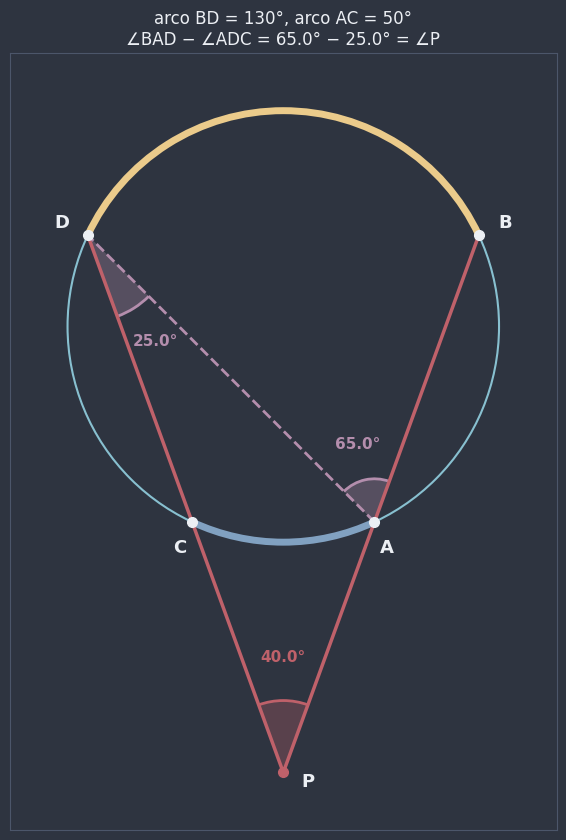

In [5]:
O, r = np.array([0.0, 0.0]), 3.0
B, D = ponto_na_circunferencia(O, r, 25), ponto_na_circunferencia(O, r, 155)  # arco BD de 130°, em cima
A_alvo, C_alvo = ponto_na_circunferencia(O, r, 295), ponto_na_circunferencia(O, r, 245)  # arco AC de 50°, embaixo
P = cruzamento(B, direcao_de(B, A_alvo), D, direcao_de(D, C_alvo))  # onde as secantes BA e DC se encontram
A = min(intersecao_reta_circunferencia(O, r, P, B), key=lambda X: math.dist(P, X))
C = min(intersecao_reta_circunferencia(O, r, P, D), key=lambda X: math.dist(P, X))

fig, ax = plt.subplots(figsize=(7.5, 8.5))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-r, P[1]), (r, r)], margem=0.8)
desenhar_circunferencia(ax, O, r, largura=1.5)
desenhar_arco_menor(ax, O, r, B, D)
desenhar_arco_menor(ax, O, r, A, C, cor=COR_ARCO_2)
for X in (B, D):
    ax.plot(*zip(P, X), color=COR_EXCENTRICO, lw=2.5, zorder=4)
ax.plot(*zip(A, D), color=COR_INSCRITO, lw=2, linestyle="--", zorder=4)
desenhar_arco(ax, P, B, D, raio=1.0, cor=COR_EXCENTRICO, rotulo=f"{medir_angulo(P, B, D):.1f}°", raio_rotulo=1.6)
desenhar_arco(ax, A, B, D, raio=0.6, cor=COR_INSCRITO, rotulo=f"{medir_angulo(A, B, D):.1f}°", raio_rotulo=1.1)
desenhar_arco(ax, D, A, C, raio=1.2, cor=COR_INSCRITO, rotulo=f"{medir_angulo(D, A, C):.1f}°", raio_rotulo=1.75)
for X, nome in ((A, "A"), (B, "B"), (C, "C"), (D, "D")):
    desenhar_ponto(ax, X, cor=NORD_TEXTO)
    rotular_fora(ax, X, nome, O, distancia=0.4, tamanho=13)
desenhar_ponto(ax, P, "P", cor=COR_EXCENTRICO, deslocamento=(0.25, -0.2))
ax.set_title(f"arco BD = {medir_angulo(O, B, D):.0f}°, arco AC = {medir_angulo(O, A, C):.0f}°\n"
             f"∠BAD − ∠ADC = {medir_angulo(A, B, D):.1f}° − {medir_angulo(D, A, C):.1f}° = ∠P", color=NORD_TEXTO,
             fontsize=12)
plt.tight_layout()
plt.show()

**Exercício 5.** O teste de quadrilátero inscritível pelos ângulos opostos.

In [6]:
# (a) Mede-se cada ângulo interno entre os dois vizinhos do vértice e testam-se as duas somas de opostos.
#     (Para um quadrilátero convexo, basta um par: se Â + Ĉ = 180°, então B̂ + D̂ = 360° − 180° = 180°.
#     Testar os dois pares é só uma garantia a mais.)
def eh_inscritivel_ex5(A, B, C, D) -> bool:
    angulo_A = medir_angulo(A, D, B)
    angulo_B = medir_angulo(B, A, C)
    angulo_C = medir_angulo(C, B, D)
    angulo_D = medir_angulo(D, C, A)
    return iguais(angulo_A + angulo_C, 180) and iguais(angulo_B + angulo_D, 180)


quadrilateros_ex5 = {
    "retângulo": [(0, 0), (5, 0), (5, 2), (0, 2)],
    "paralelogramo": [(0, 0), (5, 0), (7, 3), (2, 3)],
    "trapézio isósceles": [(0, 0), (10, 0), (7, 4), (3, 4)],
    "pipa": [(0, 0), (3, -2), (8, 0), (3, 2)],
}
respostas_ex5 = [eh_inscritivel_ex5(*vertices) for vertices in quadrilateros_ex5.values()]

linhas = []
for (nome, vertices), resposta in zip(quadrilateros_ex5.items(), respostas_ex5):
    A, B, C, D = vertices
    soma_AC = medir_angulo(A, D, B) + medir_angulo(C, B, D)
    linhas.append({"quadrilátero": nome, "Â + Ĉ": f"{soma_AC:.1f}°", "inscritível?": resposta})
display(pd.DataFrame(linhas).style.hide(axis="index"))
# A pipa tem B̂ = D̂ (é simétrica), mas Â + Ĉ ≈ 111°: não é inscritível.
# Uma pipa só é inscritível quando os dois ângulos iguais são retos.

quadrilátero,Â + Ĉ,inscritível?
retângulo,180.0°,True
paralelogramo,112.6°,False
trapézio isósceles,180.0°,True
pipa,111.0°,False


## Desafio

**Exercício 6.** As pontas do pentagrama, medidas com o transferidor e calculadas pelo teorema do ângulo inscrito.

[36.0, 36.0, 36.0, 36.0, 36.0] 180.0 72.0 36.0


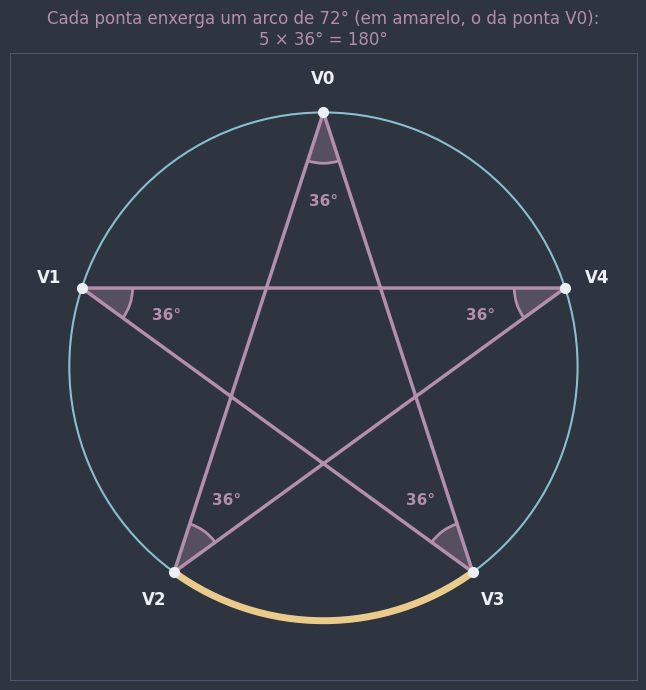

In [7]:
O_ex6 = np.array([0.0, 0.0])
vertices_ex6 = [ponto_na_circunferencia(O_ex6, 3, 90 + 72 * k) for k in range(5)]

# (a) A ponta no vértice k é formada pelos segmentos até os vértices k + 2 e k + 3 (o operador % "dá a volta").
pontas_ex6 = [medir_angulo(vertices_ex6[k], vertices_ex6[(k + 2) % 5], vertices_ex6[(k + 3) % 5]) for k in range(5)]
soma_ex6 = sum(pontas_ex6)

# (b) Os vértices k + 2 e k + 3 são vizinhos no pentágono: o arco entre eles é 360° ÷ 5 = 72°,
#     e cada ponta, inscrita, vale a metade: 36°. Cinco pontas: 5 × 36° = 180°.
arco_ponta_ex6 = arco_enxergado(O_ex6, vertices_ex6[0], vertices_ex6[2], vertices_ex6[3])
ponta_teorica_ex6 = arco_ponta_ex6 / 2

print([round(p, 6) for p in pontas_ex6], round(soma_ex6, 6), round(arco_ponta_ex6, 6), round(ponta_teorica_ex6, 6))

fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-3, -3), (3, 3)], margem=0.7)
desenhar_circunferencia(ax, O_ex6, 3, largura=1.5)
estrela = [vertices_ex6[(2 * k) % 5] for k in range(5)]  # a ordem 0, 2, 4, 1, 3 desenha a estrela
ax.add_patch(Polygon(estrela, closed=True, fill=False, edgecolor=COR_INSCRITO, lw=2.5, zorder=4))
desenhar_arco_da_circunferencia(ax, O_ex6, 3, 90 + 72 * 2, 90 + 72 * 3)  # o arco que a ponta de cima enxerga
for k, V in enumerate(vertices_ex6):
    desenhar_arco(ax, V, vertices_ex6[(k + 2) % 5], vertices_ex6[(k + 3) % 5], raio=0.6, cor=COR_INSCRITO,
                  rotulo=f"{pontas_ex6[k]:.0f}°", raio_rotulo=1.05)
    desenhar_ponto(ax, V, cor=NORD_TEXTO)
    rotular_fora(ax, V, f"V{k}", O_ex6, distancia=0.4, tamanho=12)
ax.set_title("Cada ponta enxerga um arco de 72° (em amarelo, o da ponta V0):\n5 × 36° = 180°", color=COR_INSCRITO,
             fontsize=12)
plt.tight_layout()
plt.show()

**Exercício 7.** A caça aos pontos que enxergam $\overline{AB}$ sob um ângulo reto.

58 pontos encontrados; maior desvio do raio: 0.0167


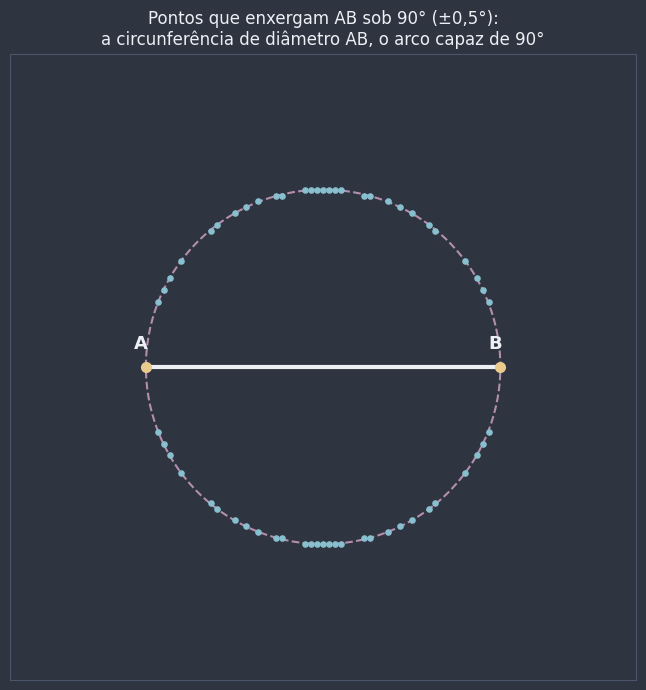

In [8]:
A_ex7, B_ex7 = np.array([-3.0, 0.0]), np.array([3.0, 0.0])
M_ex7 = ponto_medio(A_ex7, B_ex7)

# (a) Varre a grade e guarda os pontos com ângulo APB "quase" reto (a menos de 0,5°).
pontos_retos_ex7 = []
for x in np.linspace(-5, 5, 101):
    for y in np.linspace(-5, 5, 101):
        P = np.array([x, y])
        if math.dist(P, A_ex7) < 1e-9 or math.dist(P, B_ex7) < 1e-9:
            continue  # em A ou em B, o ângulo nem existe
        if abs(medir_angulo(P, A_ex7, B_ex7) - 90) < 0.5:
            pontos_retos_ex7.append(P)

# (b) Todos ficam pertinho da circunferência de diâmetro AB (centro M, raio 3).
maior_desvio_ex7 = max(abs(math.dist(P, M_ex7) - 3) for P in pontos_retos_ex7)
print(f"{len(pontos_retos_ex7)} pontos encontrados; maior desvio do raio: {maior_desvio_ex7:.4f}")

# (c) A figura: os pontos "caçados" desenham a circunferência sem que ninguém a tenha traçado.
fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor(NORD_FUNDO)
preparar_eixo(ax, [(-5, -5), (5, 5)], margem=0.3)
desenhar_circunferencia(ax, M_ex7, 3, cor=COR_INSCRITO, estilo="--", largura=1.5)
xs, ys = zip(*pontos_retos_ex7)
ax.scatter(xs, ys, color=COR_PONTO, s=14, zorder=5)
ax.plot(*zip(A_ex7, B_ex7), color=NORD_TEXTO, lw=3, zorder=4)
for P, nome in ((A_ex7, "A"), (B_ex7, "B")):
    desenhar_ponto(ax, P, nome, cor=COR_AVISO, deslocamento=(-0.2, 0.3))
ax.set_title("Pontos que enxergam AB sob 90° (±0,5°):\na circunferência de diâmetro AB, o arco capaz de 90°",
             color=NORD_TEXTO, fontsize=12)
plt.tight_layout()
plt.show()

🎯 **Para que serve:** esse é o truque do **esquadro de carpinteiro**, ao contrário. Se você precisa encontrar, numa peça redonda, as pontas de um diâmetro, basta encostar o canto de um esquadro na borda: os dois lados do esquadro cortam a borda nas pontas de um diâmetro (o ângulo reto inscrito enxerga uma semicircunferência). Repetindo com o esquadro em outra posição, os dois diâmetros se cruzam no **centro** da peça.